## Import Libraries

In [48]:
import os   
import torch
import torchvision.transforms as transforms 
import torchvision.datasets as datasets  
import random

from collections import defaultdict
from torch.utils.data import DataLoader, random_split, Subset

import torchvision.models as models 
import torch.nn as nn 
import torch.optim as optim   

from tqdm import tqdm

## Set Dataset path and Transforms

In [49]:
tran_dir = 'dataset/facial_expression_reduced'

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

## Load Dataset and Split

In [50]:
full_dataset = datasets.ImageFolder(root=tran_dir,transform=transform)

train_size = int(0.8*len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset,[train_size,val_size])

train_loader = DataLoader(train_dataset,batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)

class_names = full_dataset.classes
print(f'Classes: {class_names}')

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Load and Customize pretrained model

In [51]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_gred = False
    
# Unfreeze only the classifier
for param in model.classifier.parameters():
    param.requires_gred = True
    
# Replace the final classififcation layer to match 8 emotions
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs,len(class_names))

# Move model to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

## Define Loss Function and Optimizer

In [52]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.classifier.parameters(), lr=0.001) #lr = learning rate

print('Loss function and optimizer are set up.')

Loss function and optimizer are set up.


## Train model

In [53]:
# EPOCHS = 10
# train_losses, val_losses = [],[]
# train_accuracies, val_accuracies = [],[]

# for epoch in range(EPOCHS):
    
#     # Training phase
#     model.train()
#     train_loss, correct, total = 0.0, 0, 0
    
#     for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} - Training'):
#         inputs,labels = inputs.to(device), labels.to(device)
        
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs,labels)
#         loss.backward()
#         optimizer.step()
        
#         train_loss += loss.item()
#         _, preds = torch.max(outputs,1)
#         correct += (preds == labels).sum().item()
#         total += labels.size(0)
        
#     train_acc = correct/total
#     train_losses.append(train_loss/len(train_loader))
#     train_accuracies.append(train_acc)
    
    
#     # Validation phase
#     model.train()
#     val_loss, correct, total = 0.0, 0, 0
    
#     with torch.no_grad():
#         for inputs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} - Validation'):
#             inputs,labels = inputs.to(device), labels.to(device)
            
#             outputs = model(inputs)
#             loss = criterion(outputs,labels)
                    
#             val_loss += loss.item()
#             _, preds = torch.max(outputs,1)
#             correct += (preds == labels).sum().item()
#             total += labels.size(0)
        
#     val_acc = correct/total
#     val_losses.append(val_loss/len(val_loader))
#     val_accuracies.append(val_acc)
    
#     print(f'Epoch [{epoch+1}/{EPOCHS}] - '
#           f'Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f} |'
#           f'Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc:.4f}')
    
EPOCHS = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(train_acc)

    # Validation Phase
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Validation"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc:.4f}")

    

Epoch 1/10 - Validation: 100%|██████████| 44/44 [00:54<00:00,  1.23s/it]


Epoch [1/10] - Train Loss: 1.6350, Train Acc: 0.3650 | Val Loss: 1.5249, Val Acc: 0.4071


Epoch 2/10 - Validation: 100%|██████████| 44/44 [00:38<00:00,  1.16it/s]


Epoch [2/10] - Train Loss: 1.4583, Train Acc: 0.4466 | Val Loss: 1.4593, Val Acc: 0.4393


Epoch 3/10 - Validation: 100%|██████████| 44/44 [00:37<00:00,  1.16it/s]


...

Epoch [8/10] - Train Loss: 1.2824, Train Acc: 0.5204 | Val Loss: 1.4263, Val Acc: 0.4600


Epoch 9/10 - Validation: 100%|██████████| 44/44 [00:37<00:00,  1.19it/s]


Epoch [9/10] - Train Loss: 1.2785, Train Acc: 0.5259 | Val Loss: 1.4094, Val Acc: 0.4421


Epoch 10/10 - Validation: 100%|██████████| 44/44 [00:37<00:00,  1.17it/s]

Epoch [10/10] - Train Loss: 1.2655, Train Acc: 0.5196 | Val Loss: 1.4029, Val Acc: 0.4607


## Visualize Performance

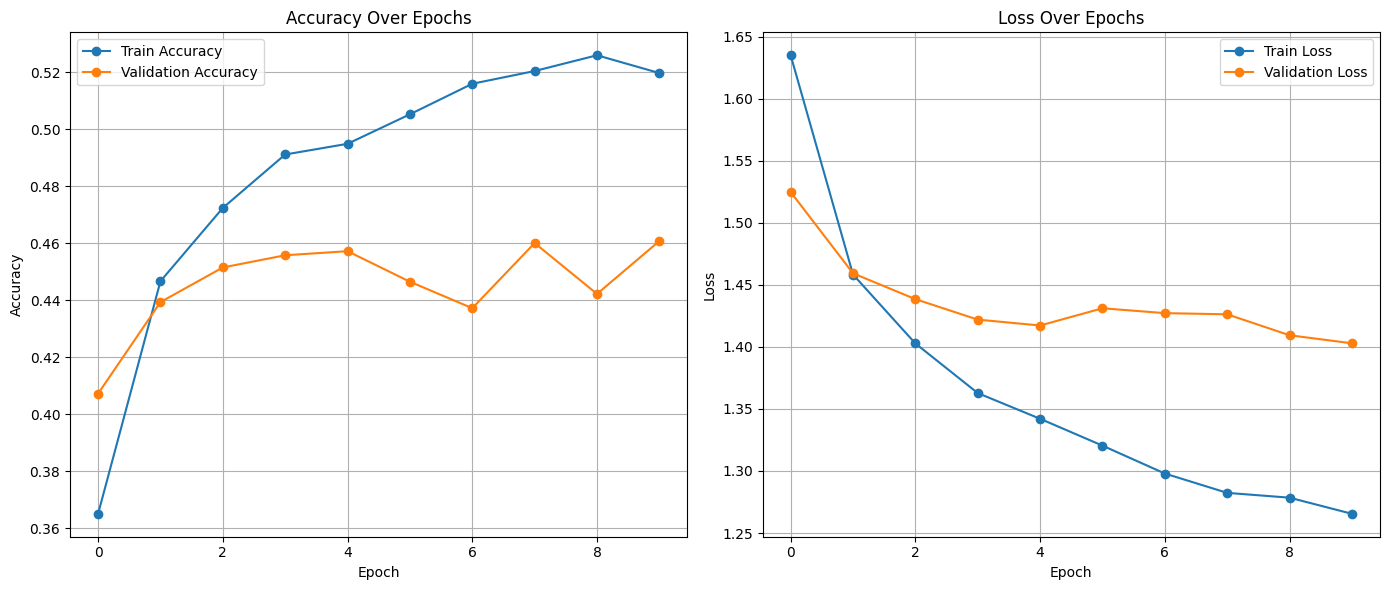

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Save the Model

In [55]:
torch.save(model.state_dict(), 'facial_expression_model.pth')
print("Model saved successfully as 'facial_expression_model.pth'")

Model saved successfully as 'facial_expression_model.pth'
